In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from imblearn.over_sampling import SMOTE
from scipy.stats import pearsonr, spearmanr, kendalltau

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

In [ ]:
file_link= 'https://drive.google.com/file/d/19E-Nt4lzKjy83nsv8-Y_aPrJu8qxlcIO/view?usp=sharing'
id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)

https://drive.google.com/uc?id=19E-Nt4lzKjy83nsv8-Y_aPrJu8qxlcIO


### Data Description

Features: 12
Data Points: 1200
Quantitative: ['Size_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Number', 'Building_Age_Years', 'Distance_to_CityCenter_km']
Categorical: ['Location', 'Has_Balcony', 'Parking_Available', 'Nearby_Schools', 'Security_Level', 'Price_Category']


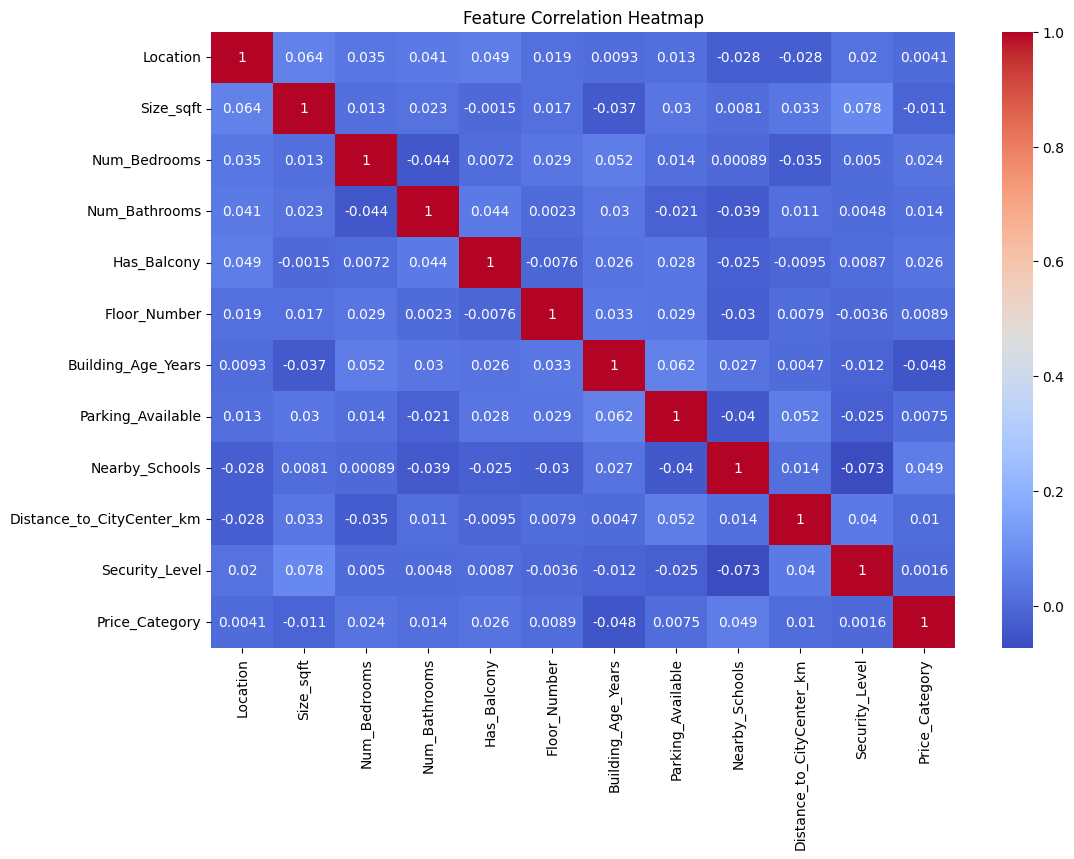

In [ ]:
# 1. Basic Stats
print(f"Features: {df.shape[1]}")
print(f"Data Points: {df.shape[0]}")

# 2. Feature Types
print("Quantitative:", df.select_dtypes(include=['number']).columns.tolist())
print("Categorical:", df.select_dtypes(include=['object']).columns.tolist())

# 3. Encoding for Heatmap
df_encoded = df.copy()
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 4. Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### **Data Analysis**

In [ ]:
df

,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,Countryside,1730.0,4.0,3.0,No,3.0,24.0,No,Few,19.2,Low,High
1,City Center,2092.0,1.0,2.0,No,16.0,36.0,No,Many,2.6,Low,High
2,Countryside,NaN,3.0,1.0,Yes,8.0,47.0,No,Many,NaN,Medium,Medium
3,NaN,1945.0,3.0,2.0,Yes,18.0,42.0,Yes,Few,28.8,Low,High
4,City Center,1505.0,4.0,3.0,No,4.0,37.0,No,Many,2.8,Low,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Suburbs,2385.0,1.0,3.0,Yes,12.0,24.0,No,Many,24.1,Low,High
1196,City Center,2095.0,4.0,3.0,Yes,14.0,8.0,Yes,Many,12.2,High,High
1197,Suburbs,487.0,4.0,NaN,No,0.0,26.0,Yes,Few,10.4,Low,Medium
1198,Countryside,1380.0,2.0,3.0,NaN,10.0,0.0,Yes,Many,7.4,Medium,High


In [ ]:
df.head(15)

,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,Countryside,1730.0,4.0,3.0,No,3.0,24.0,No,Few,19.2,Low,High
1,City Center,2092.0,1.0,2.0,No,16.0,36.0,No,Many,2.6,Low,High
2,Countryside,NaN,3.0,1.0,Yes,8.0,47.0,No,Many,NaN,Medium,Medium
3,NaN,1945.0,3.0,2.0,Yes,18.0,42.0,Yes,Few,28.8,Low,High
4,City Center,1505.0,4.0,3.0,No,4.0,37.0,No,Many,2.8,Low,High
5,City Center,2154.0,1.0,3.0,Yes,5.0,40.0,Yes,Many,16.2,High,High
6,Countryside,866.0,2.0,NaN,No,2.0,44.0,Yes,Few,9.4,High,High
7,Suburbs,NaN,3.0,2.0,No,NaN,23.0,No,Few,12.1,High,Medium
8,Countryside,2234.0,4.0,2.0,Yes,19.0,NaN,Yes,NaN,5.8,NaN,High
9,Countryside,1632.0,1.0,1.0,NaN,NaN,NaN,No,Many,17.6,NaN,High


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   1060 non-null   object 
 1   Size_sqft                  1094 non-null   float64
 2   Num_Bedrooms               1064 non-null   float64
 3   Num_Bathrooms              1057 non-null   float64
 4   Has_Balcony                1079 non-null   object 
 5   Floor_Number               1068 non-null   float64
 6   Building_Age_Years         1073 non-null   float64
 7   Parking_Available          1099 non-null   object 
 8   Nearby_Schools             1076 non-null   object 
 9   Distance_to_CityCenter_km  1097 non-null   float64
 10  Security_Level             1074 non-null   object 
 11  Price_Category             1200 non-null   object 
dtypes: float64(6), object(6)
memory usage: 112.6+ KB
None


In [ ]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 6 numerical features: 

['Size_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Number', 'Building_Age_Years', 'Distance_to_CityCenter_km']


In [ ]:
categorical_data=df.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 6 categorical features: 

['Location', 'Has_Balcony', 'Parking_Available', 'Nearby_Schools', 'Security_Level', 'Price_Category']


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Size_sqft,1094.0,1379.874771,639.971957,301.0,821.25,1343.0,1930.25,2499.0
Num_Bedrooms,1064.0,2.514098,1.129352,1.0,1.00,3.0,4.00,4.0
Num_Bathrooms,1057.0,1.970672,0.826921,1.0,1.00,2.0,3.00,3.0
Floor_Number,1068.0,9.764045,5.774629,0.0,5.00,10.0,15.00,19.0
Building_Age_Years,1073.0,23.829450,14.241186,0.0,12.00,23.0,36.00,49.0
Distance_to_CityCenter_km,1097.0,14.807475,8.368203,0.5,7.60,14.7,21.60,30.0


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Location,1060,3,City Center,369
Has_Balcony,1079,2,No,549
Parking_Available,1099,2,No,558
Nearby_Schools,1076,2,Few,542
Security_Level,1074,3,High,367
Price_Category,1200,3,Medium,413


In [ ]:
numerical_data.var()

,0
Size_sqft,409564.105987
Num_Bedrooms,1.275436
Num_Bathrooms,0.683798
Floor_Number,33.346335
Building_Age_Years,202.811371
Distance_to_CityCenter_km,70.026824


In [ ]:
numerical_data.skew()

,0
Size_sqft,0.048548
Num_Bedrooms,-0.037031
Num_Bathrooms,0.054632
Floor_Number,-0.074779
Building_Age_Years,0.058064
Distance_to_CityCenter_km,0.061188


**Skewness Interpretation:**

*   Size_Sqft(0.0485)- Very close to zero, meaning the data is evenly distributed around the mean.
*   Num_bedrooms(-0.0370)-Slight negative skew (left-tailed), but effectively negligible

*   Num_Bathrooms(0.0546)-Negligible positive skew (right-tailed).
*   Floor_Numbers(-0.0748)-The distribution of floors is balanced across the range.

*   Building_Age_Years(0.0581)- No significant bias toward very old or very new buildings.
*   Distance_to_CityCentre_km(0.0612)-Distribution of distances is near-normal.












In [ ]:
# Check Unique Values
df.nunique()

,0
Location,3
Size_sqft,841
Num_Bedrooms,4
Num_Bathrooms,3
Has_Balcony,2
Floor_Number,20
Building_Age_Years,50
Parking_Available,2
Nearby_Schools,2
Distance_to_CityCenter_km,291


In [ ]:
# Check for missing values
df.isnull().sum()

,0
Location,140
Size_sqft,106
Num_Bedrooms,136
Num_Bathrooms,143
Has_Balcony,121
Floor_Number,132
Building_Age_Years,127
Parking_Available,101
Nearby_Schools,124
Distance_to_CityCenter_km,103


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify the fix
print(df.isnull().sum())

Location                     0
Size_sqft                    0
Num_Bedrooms                 0
Num_Bathrooms                0
Has_Balcony                  0
Floor_Number                 0
Building_Age_Years           0
Parking_Available            0
Nearby_Schools               0
Distance_to_CityCenter_km    0
Security_Level               0
Price_Category               0
dtype: int64


In [ ]:

duplicate_mask = df.duplicated()

print(df[df.duplicated()])

Empty DataFrame
Columns: [Location, Size_sqft, Num_Bedrooms, Num_Bathrooms, Has_Balcony, Floor_Number, Building_Age_Years, Parking_Available, Nearby_Schools, Distance_to_CityCenter_km, Security_Level, Price_Category]
Index: []


### **Imbalance Check**

--- Class Distribution ---
Price_Category
Medium    413
Low       402
High      385
Name: count, dtype: int64

--- Percentage Distribution ---
Price_Category
Medium    34.416667
Low       33.500000
High      32.083333
Name: proportion, dtype: float64


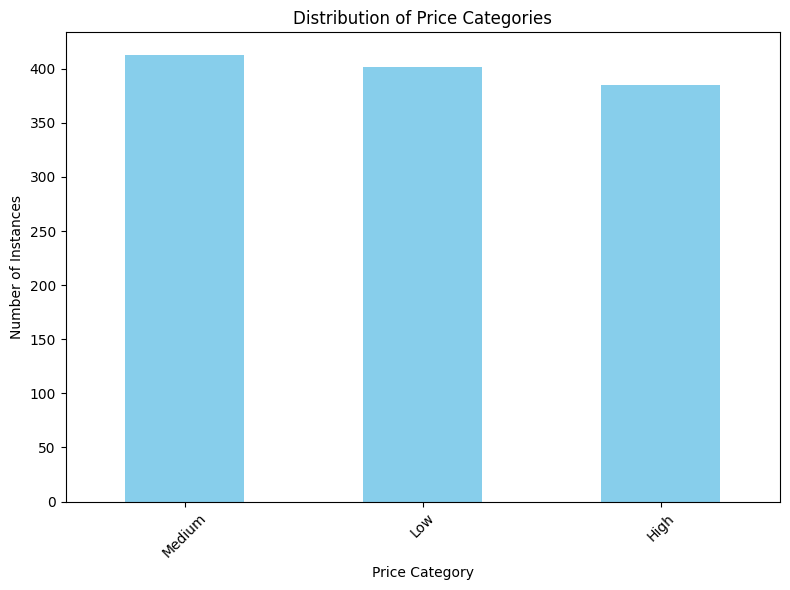

In [ ]:
import pandas as pd
import matplotlib.pyplot as pd_plt

# Calculating counts and percentages for Price_Category
class_counts = df['Price_Category'].value_counts()
percentage_dist = df['Price_Category'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(class_counts)
print("\n--- Percentage Distribution ---")
print(percentage_dist)

# Plotting the distribution
pd_plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color='skyblue')
pd_plt.title('Distribution of Price Categories')
pd_plt.xlabel('Price Category')
pd_plt.ylabel('Number of Instances')
pd_plt.xticks(rotation=45)
pd_plt.tight_layout()
pd_plt.savefig('class_distribution.png')
pd_plt.show()

In [ ]:
from sklearn.utils import resample
max_size = df['Price_Category'].value_counts().max()
balanced_list = [resample(df[df['Price_Category'] == cls],
                          replace=True,
                          n_samples=max_size,
                          random_state=42) for cls in df['Price_Category'].unique()]
df_balanced = pd.concat(balanced_list)
# 2. Select numerical features from the balanced dataframe
features = ['Size_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Number', 'Building_Age_Years', 'Distance_to_CityCenter_km']
data_to_cluster = df_balanced[features].copy()

# 3. Scale the balanced data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_cluster)
# Verify the balance
print("New Class Distribution:")
print(df_balanced['Price_Category'].value_counts())

New Class Distribution:
Price_Category
High      413
Medium    413
Low       413
Name: count, dtype: int64


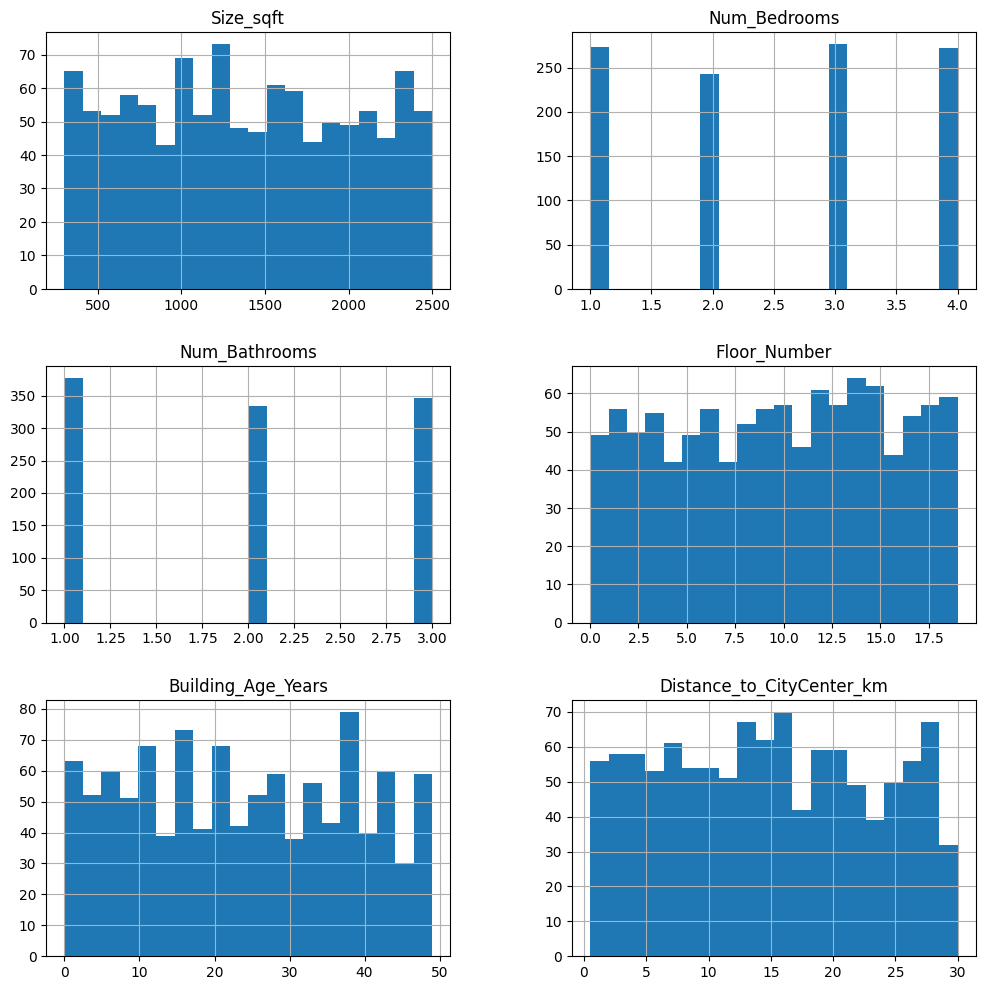

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

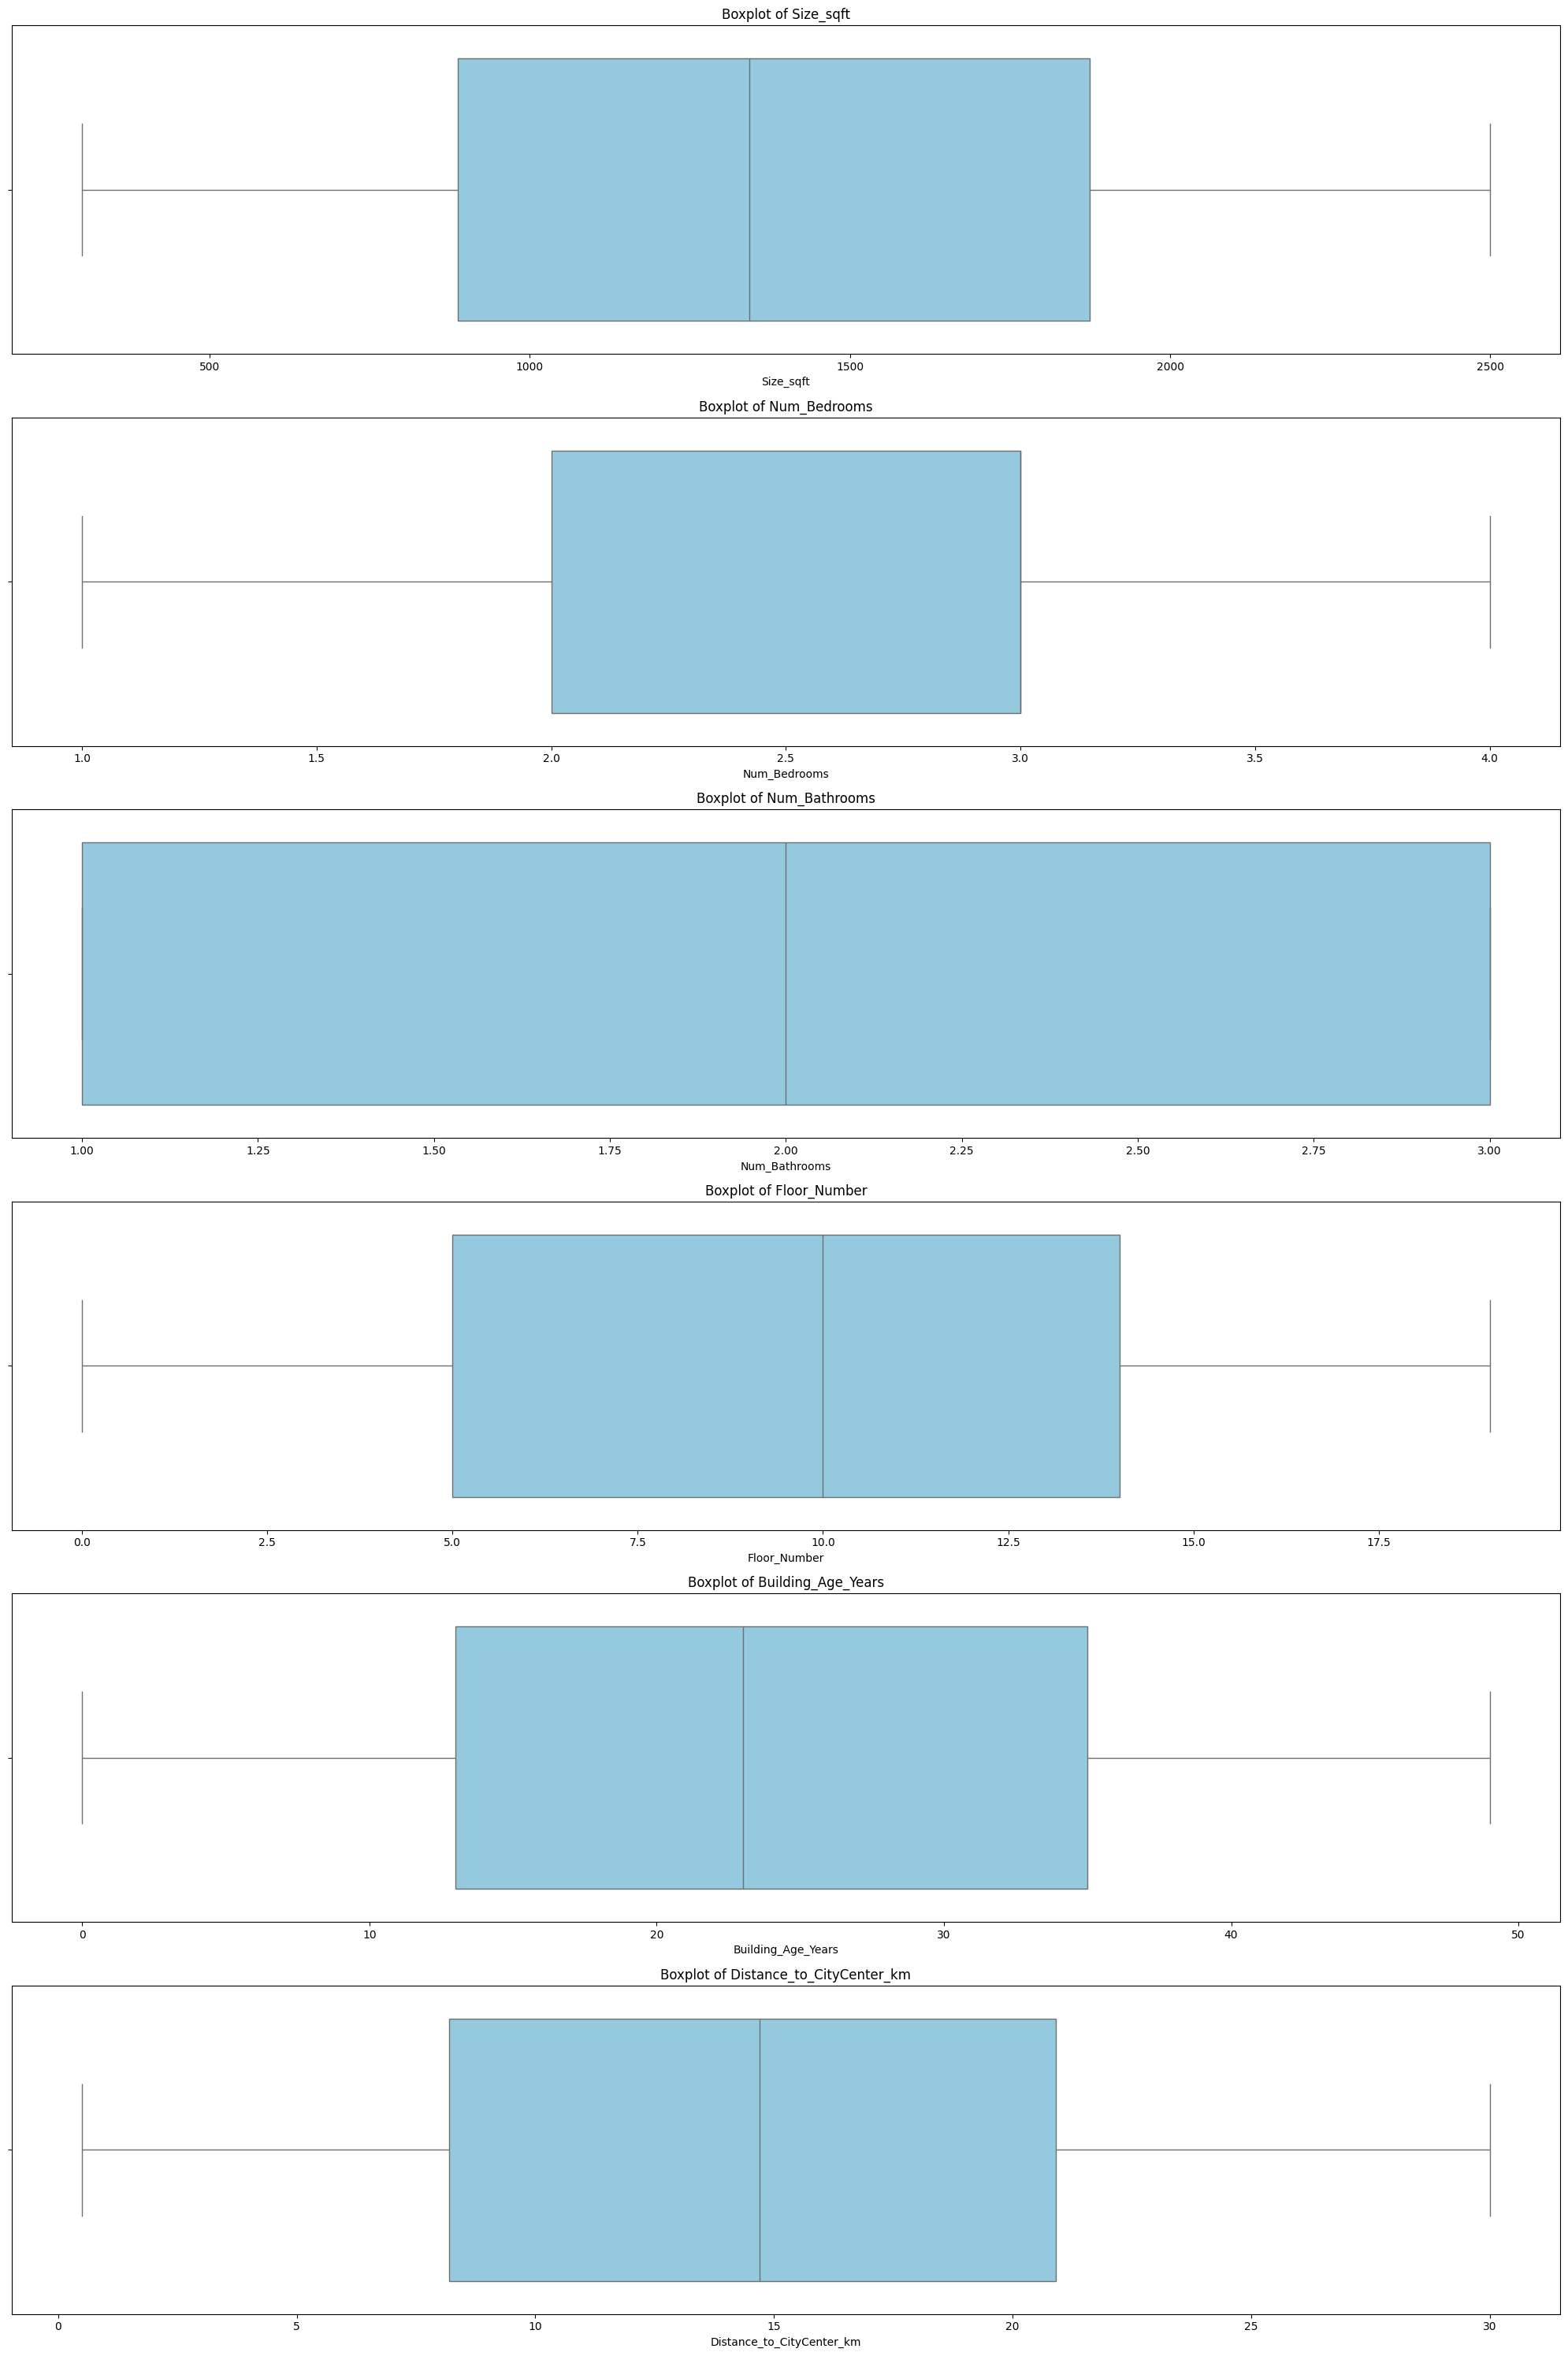

In [ ]:
# Select only numerical columns for boxplot analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


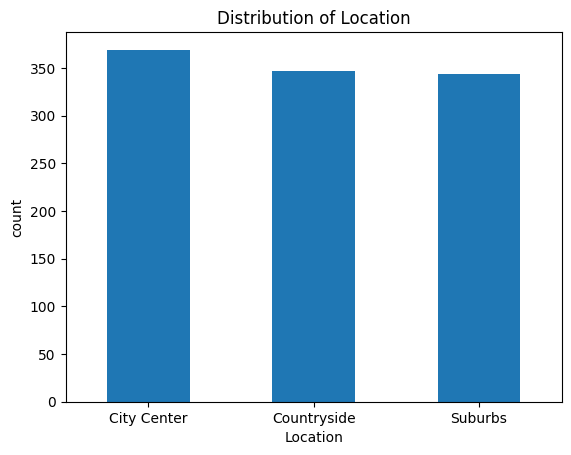

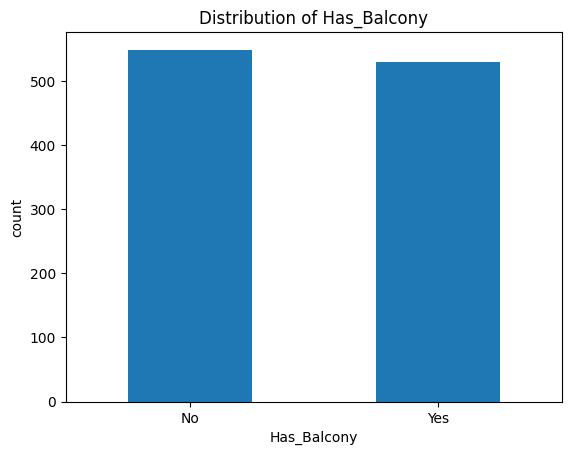

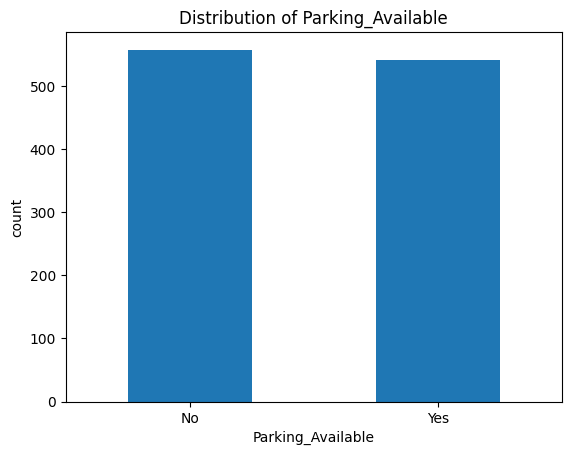

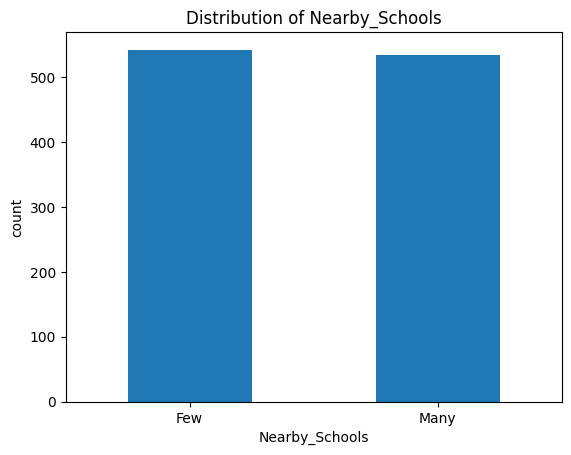

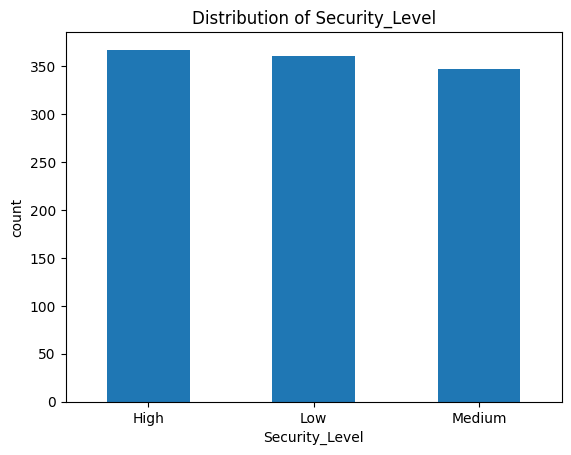

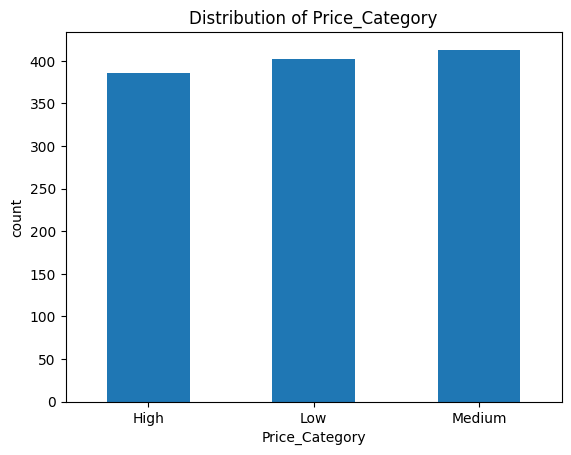

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

### **Correlation Analysis**

In [ ]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,Size_sqft,Num_Bedrooms,Num_Bathrooms,Floor_Number,Building_Age_Years,Distance_to_CityCenter_km
Size_sqft,1.000000,0.012727,0.022786,0.017399,-0.037013,0.033256
Num_Bedrooms,0.012727,1.000000,-0.044169,0.029356,0.052383,-0.035343
Num_Bathrooms,0.022786,-0.044169,1.000000,0.002315,0.029806,0.011478
Floor_Number,0.017399,0.029356,0.002315,1.000000,0.032759,0.007869
Building_Age_Years,-0.037013,0.052383,0.029806,0.032759,1.000000,0.004747
Distance_to_CityCenter_km,0.033256,-0.035343,0.011478,0.007869,0.004747,1.000000


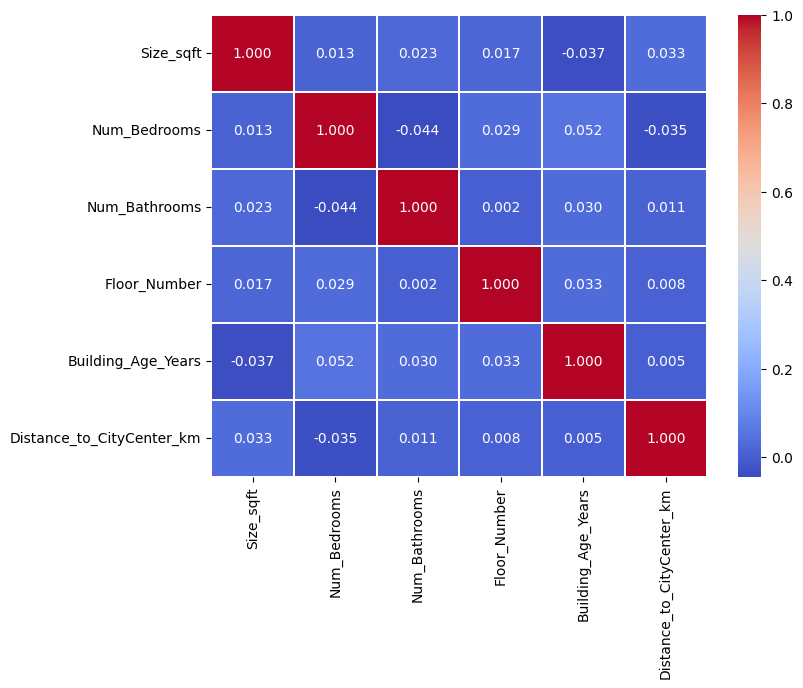

In [ ]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

In [ ]:
corr_pearson = numerical_data.corr(method='pearson')
corr_spearman = numerical_data.corr(method='spearman')
corr_kendall = numerical_data.corr(method='kendall')

print("Pearson Correlation:\n", corr_pearson)
print("\nSpearman Correlation:\n", corr_spearman)
print("\nKendall Correlation:\n", corr_kendall)

Pearson Correlation:
                            Size_sqft  Num_Bedrooms  Num_Bathrooms  \
Size_sqft                   1.000000      0.012727       0.022786   
Num_Bedrooms                0.012727      1.000000      -0.044169   
Num_Bathrooms               0.022786     -0.044169       1.000000   
Floor_Number                0.017399      0.029356       0.002315   
Building_Age_Years         -0.037013      0.052383       0.029806   
Distance_to_CityCenter_km   0.033256     -0.035343       0.011478   

                           Floor_Number  Building_Age_Years  \
Size_sqft                      0.017399           -0.037013   
Num_Bedrooms                   0.029356            0.052383   
Num_Bathrooms                  0.002315            0.029806   
Floor_Number                   1.000000            0.032759   
Building_Age_Years             0.032759            1.000000   
Distance_to_CityCenter_km      0.007869            0.004747   

                           Distance_to_CityCenter_km

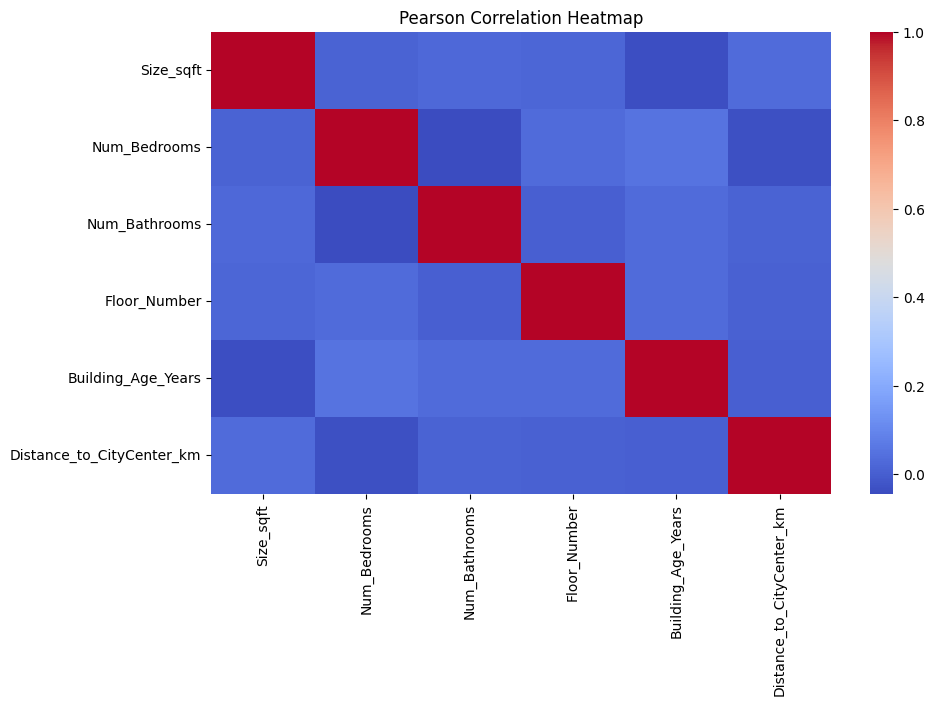

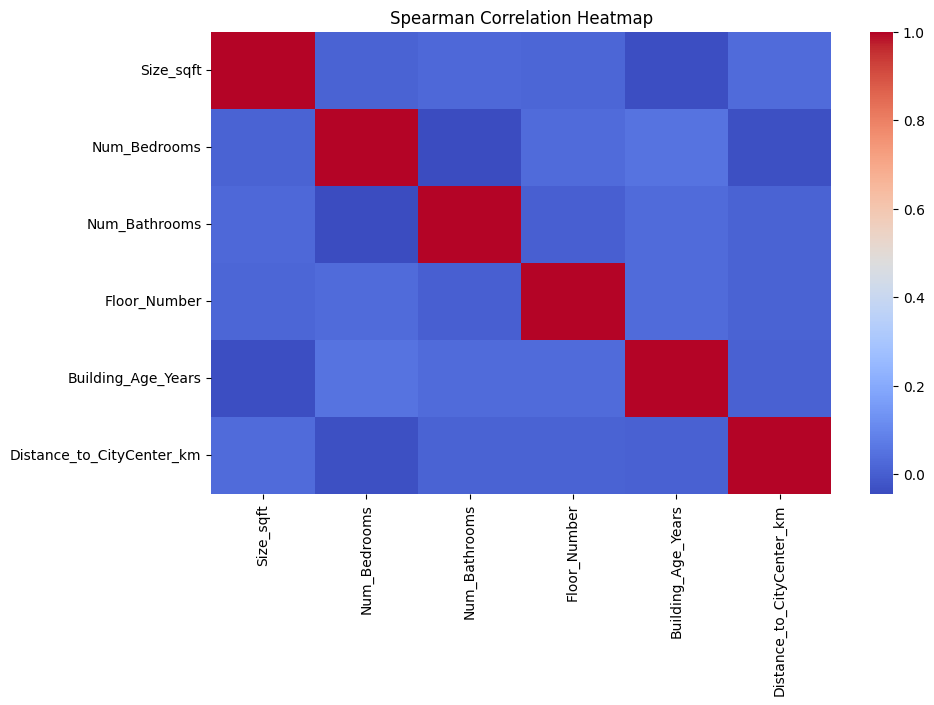

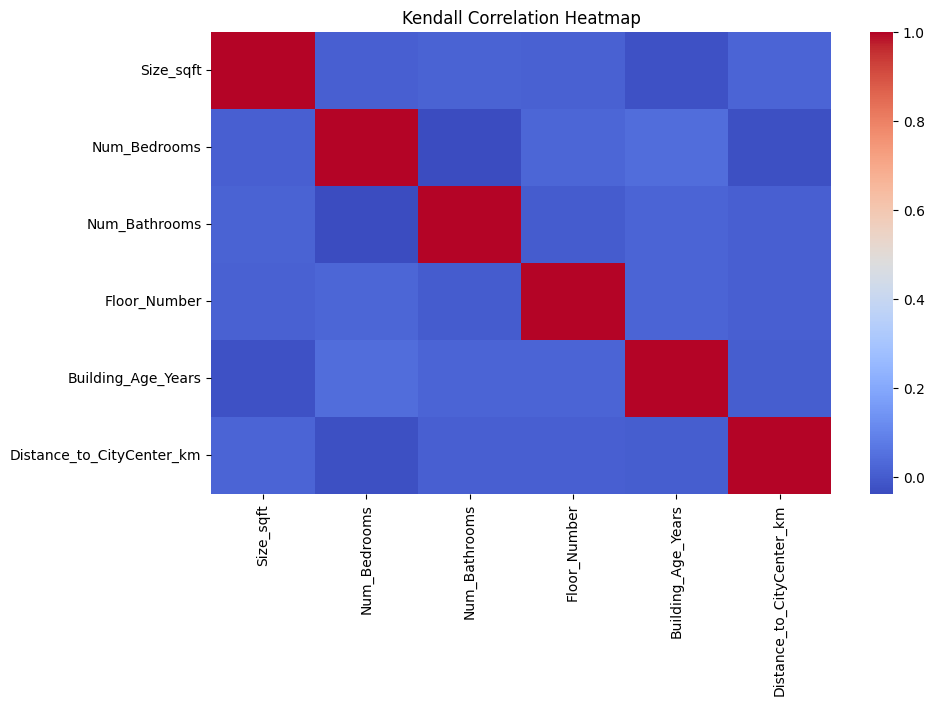

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_pearson, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman, cmap='coolwarm')
plt.title("Spearman Correlation Heatmap")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(corr_kendall, cmap='coolwarm')
plt.title("Kendall Correlation Heatmap")
plt.show()

In [ ]:
# 1. Define the importance mappings
security_mapping = {'low': 1, 'medium': 2, 'high': 3}
school_mapping = {'few': 1, 'many': 2}

# 2. Apply mapping to Security_Level
df['Security_Level'] = df['Security_Level'].str.lower().map(security_mapping)

# 3. Apply mapping to Nearby_Schools
df['Nearby_Schools'] = df['Nearby_Schools'].str.lower().map(school_mapping)

# Display the results
df[['Security_Level', 'Nearby_Schools', 'Price_Category']].head()
df

,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,Countryside,1730.0,4.0,3.0,No,3.0,24.0,No,1,19.2,1,High
1,City Center,2092.0,1.0,2.0,No,16.0,36.0,No,2,2.6,1,High
2,Countryside,1343.0,3.0,1.0,Yes,8.0,47.0,No,2,14.7,2,Medium
3,City Center,1945.0,3.0,2.0,Yes,18.0,42.0,Yes,1,28.8,1,High
4,City Center,1505.0,4.0,3.0,No,4.0,37.0,No,2,2.8,1,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Suburbs,2385.0,1.0,3.0,Yes,12.0,24.0,No,2,24.1,1,High
1196,City Center,2095.0,4.0,3.0,Yes,14.0,8.0,Yes,2,12.2,3,High
1197,Suburbs,487.0,4.0,2.0,No,0.0,26.0,Yes,1,10.4,1,Medium
1198,Countryside,1380.0,2.0,3.0,No,10.0,0.0,Yes,2,7.4,2,High


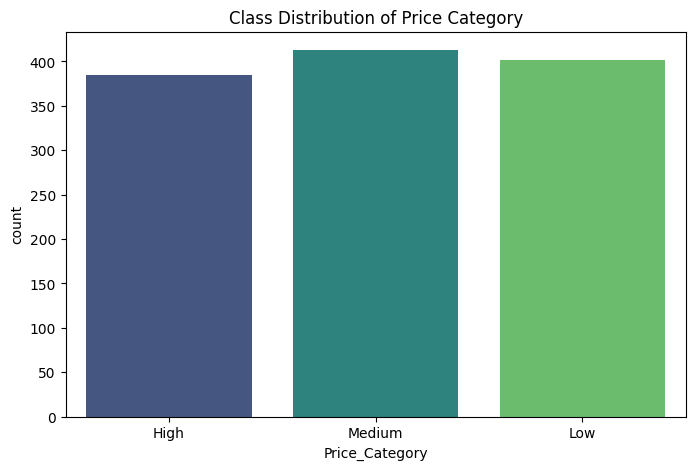

Price Category Counts:
Price_Category
Medium    413
Low       402
High      385
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.get_dummies(df, columns=['Location'], drop_first=True)

# Showing the class distribution of Price_Category to explain why SMOTE might be needed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Price_Category', hue='Price_Category', palette='viridis')
plt.title('Class Distribution of Price Category')
plt.savefig('class_dist.png')
plt.show()

print("Price Category Counts:")
print(df['Price_Category'].value_counts())

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Identify the numerical columns in your flat dataset
num_cols = [
    'Size_sqft',
    'Num_Bedrooms',
    'Num_Bathrooms',
    'Floor_Number',
    'Building_Age_Years',
    'Distance_to_CityCenter_km'
]

# 2. Apply StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 3. Display the result
print("--- Preprocessing Complete (Numerical Scaling) ---")
print(df[num_cols].head()) # Values should now be centered around 0

# 4. Save the scaled dataset for your ML model
df.to_csv('Preprocessed_Flat_Price_Data.csv', index=False)

--- Preprocessing Complete (Numerical Scaling) ---
   Size_sqft  Num_Bedrooms  Num_Bathrooms  Floor_Number  Building_Age_Years  \
0   0.578497      1.332205       1.322327     -1.246850            0.019189   
1   1.171101     -1.461003       0.033300      1.140344            0.910543   
2  -0.055033      0.401136      -1.255727     -0.328698            1.727618   
3   0.930458      0.401136       0.033300      1.507605            1.356220   
4   0.210166      1.332205       1.322327     -1.063220            0.984823   

   Distance_to_CityCenter_km  
0                   0.550396  
1                  -1.525273  
2                  -0.012285  
3                   1.750783  
4                  -1.500265  


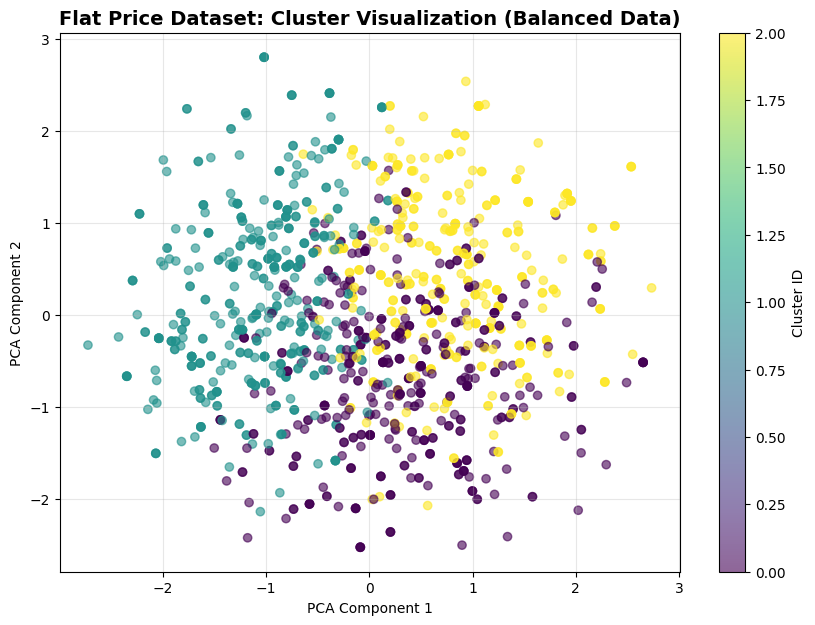

In [ ]:
# 4. Run KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data_to_cluster['Cluster'] = kmeans.fit_predict(scaled_data)

# 5. Visualize using PCA
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(components[:, 0], components[:, 1], c=data_to_cluster['Cluster'], cmap='viridis', alpha=0.6)
plt.title('Flat Price Dataset: Cluster Visualization (Balanced Data)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(alpha=0.3)
plt.show()

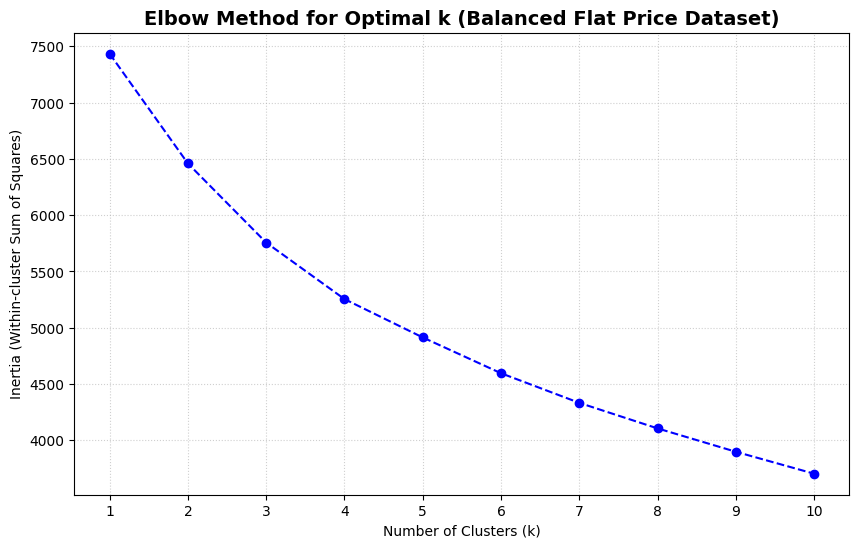

In [ ]:
# 4. Calculate Inertia for balanced data
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

# 5. Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title("Elbow Method for Optimal k (Balanced Flat Price Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster Sum of Squares)")
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('elbow_method_balanced.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


df_ml = pd.get_dummies(df_balanced, columns=['Location', 'Has_Balcony', 'Parking_Available', 'Nearby_Schools', 'Security_Level'], drop_first=True)


X = df_ml.drop(['Price_Category'], axis=1)
y = df_ml['Price_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 4. Verify the shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_scaled shape: (991, 13)
X_test_scaled shape: (248, 13)
y_train shape: (991,)
y_test shape: (248,)


In [ ]:
# 4. Train Model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

# 5. Predict and Evaluate
dt_pred = dt_model.predict(X_test)

print("--- Decision Tree Performance (Balanced Dataset) ---")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(classification_report(y_test, dt_pred))

--- Decision Tree Performance (Balanced Dataset) ---
Accuracy: 0.6895
              precision    recall  f1-score   support

        High       0.81      0.67      0.74        85
         Low       0.64      0.68      0.66        76
      Medium       0.64      0.71      0.67        87

    accuracy                           0.69       248
   macro avg       0.70      0.69      0.69       248
weighted avg       0.70      0.69      0.69       248



In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=2000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# 3. Formatted Output
print("--- Logistic Regression Performance (Balanced & Scaled) ---")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))

--- Logistic Regression Performance (Balanced & Scaled) ---
Accuracy: 0.3790
              precision    recall  f1-score   support

        High       0.37      0.35      0.36        85
         Low       0.38      0.47      0.42        76
      Medium       0.40      0.32      0.36        87

    accuracy                           0.38       248
   macro avg       0.38      0.38      0.38       248
weighted avg       0.38      0.38      0.38       248



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

# 2. Predict and Evaluate
nn_pred = nn_model.predict(X_test)

print("--- Neural Network Performance (Balanced & Scaled) ---")
print(f"Accuracy: {accuracy_score(y_test, nn_pred):.4f}")
print(classification_report(y_test, nn_pred))

--- Neural Network Performance (Balanced & Scaled) ---
Accuracy: 0.3589
              precision    recall  f1-score   support

        High       0.36      0.35      0.36        85
         Low       0.56      0.18      0.28        76
      Medium       0.32      0.52      0.40        87

    accuracy                           0.36       248
   macro avg       0.41      0.35      0.34       248
weighted avg       0.41      0.36      0.35       248



In [ ]:
models = {
    "Decision Tree": dt_model,
    "Logistic Regression": lr_model,
    "Neural Network": nn_model
}

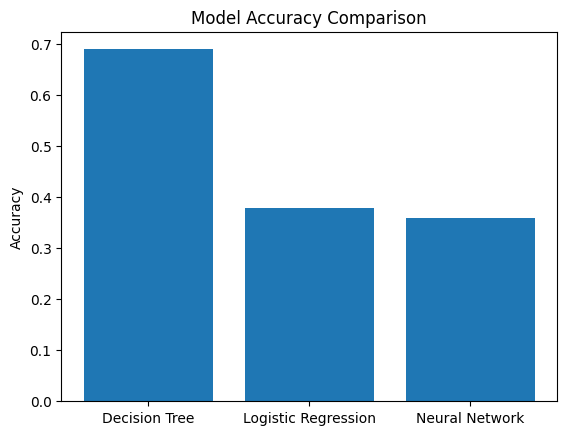

In [ ]:
accuracies = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, y_pred)

plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
precision_scores = {}
recall_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    precision_scores[name] = precision_score(y_test, y_pred, average='weighted')
    recall_scores[name] = recall_score(y_test, y_pred, average='weighted')

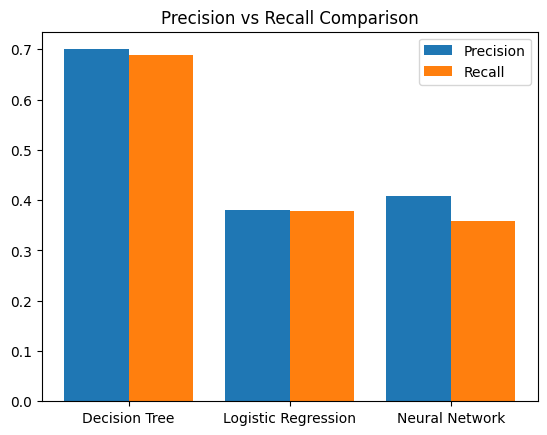

In [ ]:
x = np.arange(len(models))

plt.bar(x - 0.2, precision_scores.values(), 0.4, label='Precision')
plt.bar(x + 0.2, recall_scores.values(), 0.4, label='Recall')

plt.xticks(x, precision_scores.keys())
plt.title("Precision vs Recall Comparison")
plt.legend()
plt.show()

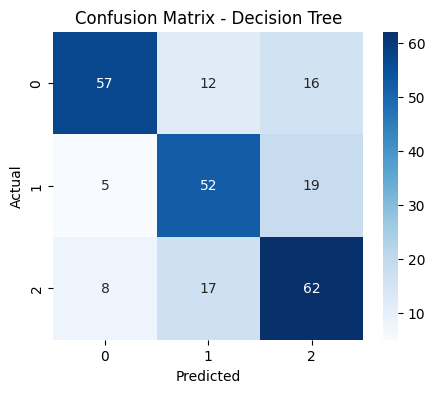

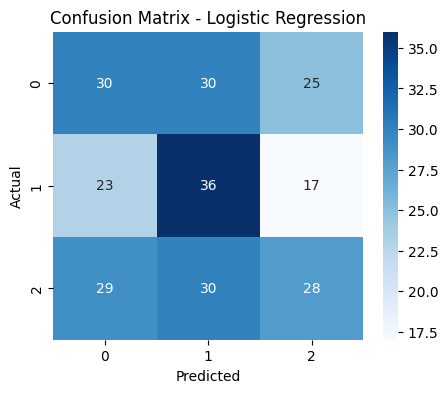

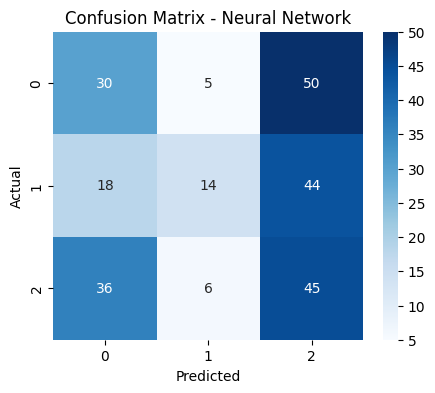

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

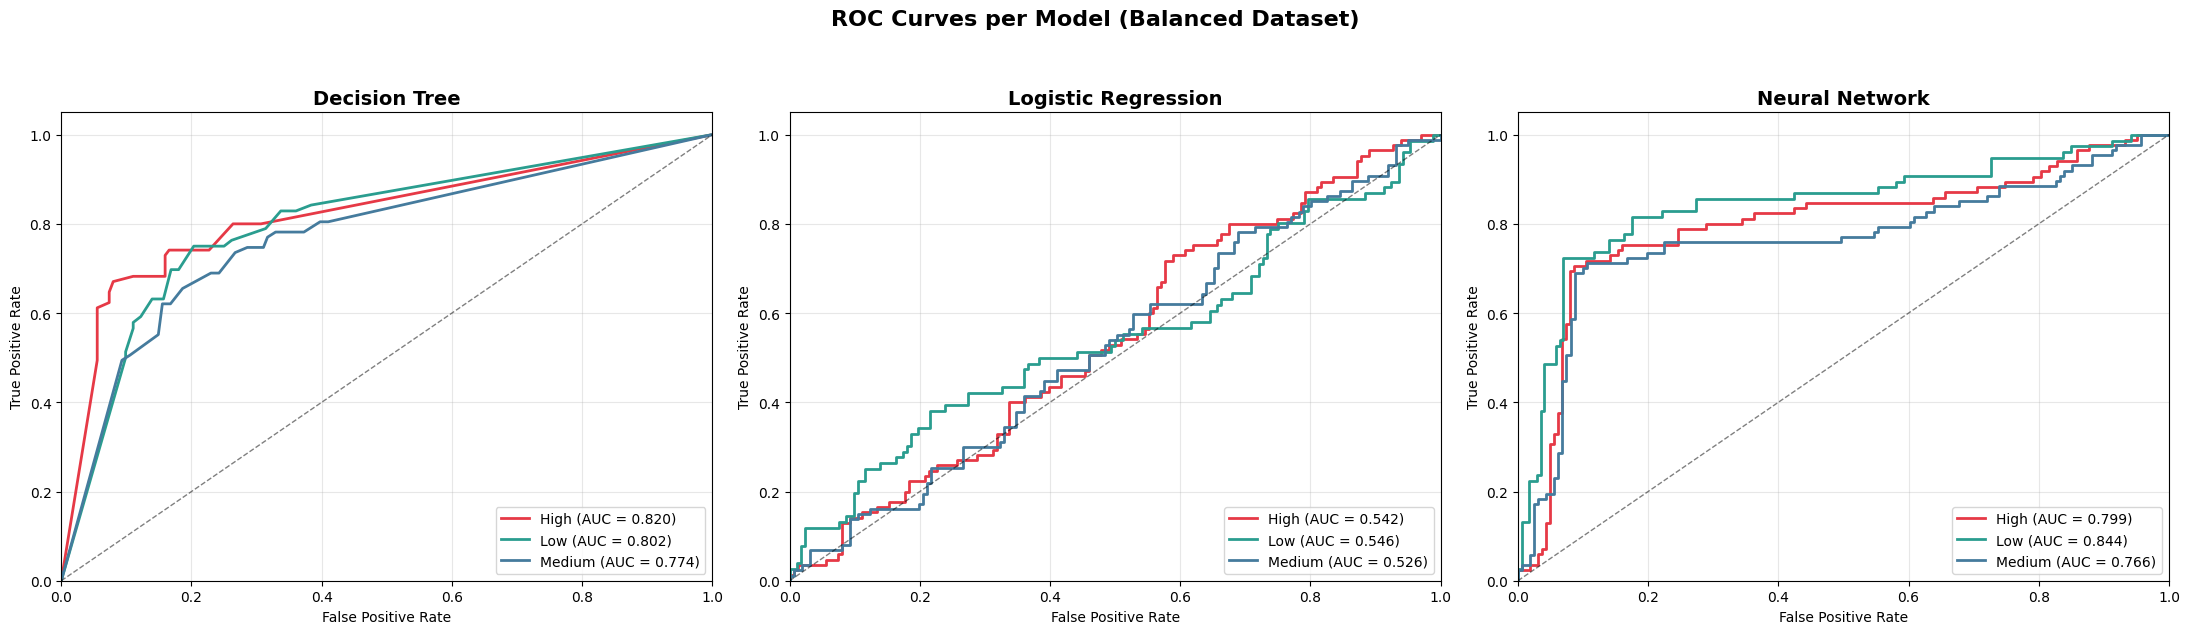

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = ['High', 'Low', 'Medium']
y_test_bin = label_binarize(y_test, classes=classes)

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42)
}

colors = ['#e63946', '#2a9d8f', '#457b9d']
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('ROC Curves per Model (Balanced Dataset)', fontsize=16, fontweight='bold', y=1.05)

for ax, (name, model) in zip(axes, models.items()):
    if name == 'Decision Tree':
        model.fit(X_train, y_train)
        y_score = model.predict_proba(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_score = model.predict_proba(X_test_scaled)

    # Calculate ROC for each class
    for i, (cls_name, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc:.3f})')

    # Formatting each subplot
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


===== AUC Score Summary (One-vs-Rest) =====
                       High     Low  Medium  Macro AUC
Model                                                 
Decision Tree        0.8199  0.8016  0.7738     0.7984
Logistic Regression  0.5425  0.5455  0.5257     0.5379
Neural Network       0.7989  0.8442  0.7661     0.8031


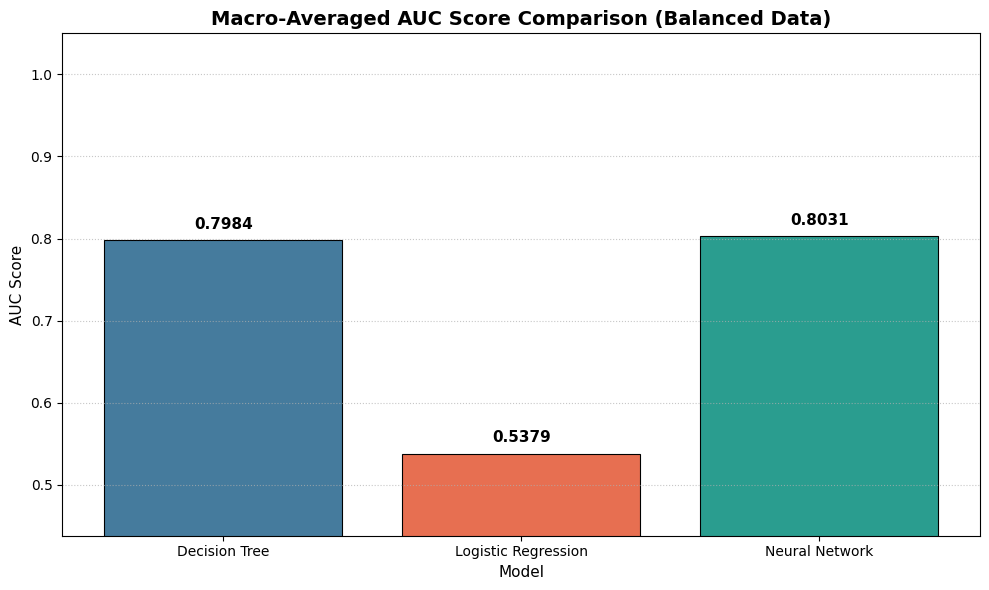

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

auc_summary = {}
classes = ['High', 'Low', 'Medium']


for name, model in models.items():
    X_input = X_test_scaled if name != 'Decision Tree' else X_test
    y_score = model.predict_proba(X_input)

    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

    class_aucs = {cls: round(roc_auc_score(y_test_bin[:, i], y_score[:, i]), 4)
                  for i, cls in enumerate(classes)}

    auc_summary[name] = {**class_aucs, 'Macro AUC': round(macro_auc, 4)}

auc_df = pd.DataFrame(auc_summary).T
auc_df.index.name = 'Model'
print('\n===== AUC Score Summary (One-vs-Rest) =====')
print(auc_df.to_string())

# 4. Bar chart: Macro AUC comparison
macro_aucs = {name: vals['Macro AUC'] for name, vals in auc_summary.items()}
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(macro_aucs.keys(), macro_aucs.values(),
              color=['#457b9d', '#e76f51', '#2a9d8f'], edgecolor='black', linewidth=0.8)

# Set dynamic limits for clarity
min_val = min(macro_aucs.values())
ax.set_ylim(max(0.0, min_val - 0.1), 1.05)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Macro-Averaged AUC Score Comparison (Balanced Data)', fontsize=14, fontweight='bold')
ax.set_ylabel('AUC Score', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()